In [2]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

In [3]:
df_india = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()


In [4]:
df_india['salary_year_avg']

38       NaN
194      NaN
691      NaN
963      NaN
1336     NaN
          ..
782917   NaN
784121   NaN
784307   NaN
785181   NaN
785715   NaN
Name: salary_year_avg, Length: 2056, dtype: float64

(0.0, 130000.0)

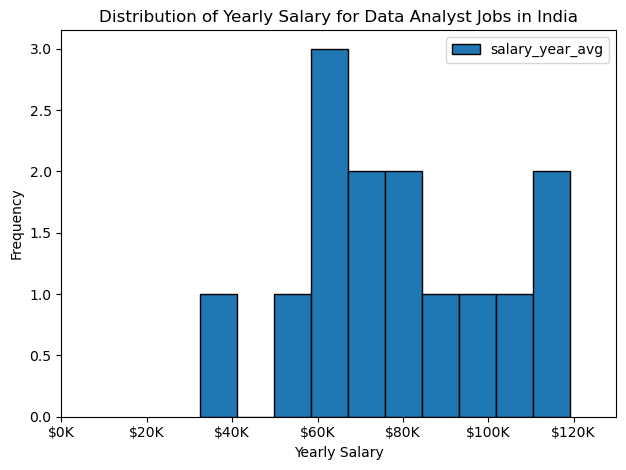

In [ ]:
df_india.plot(kind='hist', y='salary_year_avg', bins=10, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.title('Distribution of Yearly Salary for Data Analyst Jobs in India')
plt.xlabel('Yearly Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.xlim(0, 130000)